# Player Similarity Analysis

## Problem Statement

A sports organization wants to identify players who have similar statistical profiles.
The objective of this project is to analyze football player statistics and build a
machine learning system that can identify players with similar performance profiles.

## Objectives
- Understand and explore the football player dataset.
- Clean and preprocess the raw dataset.
- Select meaningful performance features.
- Apply feature scaling.
- Use PCA for dimensionality reduction and visualization.
- Apply multiple unsupervised learning algorithms.
- Compare clustering models using evaluation metrics.
- Use Cosine Similarity to find the Top 5 most similar players.
- Develop a foundation for a player recommendation system.

## Machine Learning Approach

This is primarily an unsupervised learning problem because there is no predefined
target variable indicating which players are similar.

Algorithms used:
1. K-Means Clustering
2. Agglomerative Clustering
3. DBSCAN
4. Gaussian Mixture Model
5. Cosine Similarity for player recommendation

In [1]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
# Loading Dataset

import pandas as pd

file_path = "/content/players_data-2024_2025.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

display(df.head())

print("\nRandom Sample:")
display(df.sample(5))

FileNotFoundError: [Errno 2] No such file or directory: '/content/players_data-2024_2025.csv'

In [ ]:
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all").T)

print("\nNumber of Columns:", len(df.columns))
print("Number of Rows:", len(df))

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Columns: 267 entries, Rk to AvgDist
dtypes: float64(111), int64(121), str(35)
memory usage: 5.8 MB

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rk,2854.0,NaN,NaN,NaN,1427.5,824.023159,1.0,714.25,1427.5,2140.75,2854.0
Player,2854,2702,Max Aarons,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nation,2847,113,es ESP,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pos,2854,10,DF,859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Squad,2854,96,Como,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Stp,212.0,NaN,NaN,NaN,14.377358,13.874832,0.0,2.0,10.5,22.0,64.0
Stp%,211.0,NaN,NaN,NaN,6.159716,4.074863,0.0,4.0,5.6,7.9,33.3
#OPA,212.0,NaN,NaN,NaN,18.768868,18.276921,0.0,3.0,14.0,30.25,89.0
#OPA/90,212.0,NaN,NaN,NaN,1.164528,1.00875,0.0,0.67,1.0,1.47,10.0



Number of Columns: 267
Number of Rows: 2854


In [ ]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
}).sort_values("Missing Percentage", ascending=False)

display(missing_table.head(20))

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Unique players
print("Total Rows:", len(df))
print("Unique Players:", df["Player"].nunique())

# Repeated player names
print("Repeated Player Records:", df["Player"].duplicated().sum())

,Missing Values,Missing Percentage
CS%,2651,92.887176
PSxG/SoT,2648,92.782060
Save%,2648,92.782060
AvgDist,2646,92.711983
Cmp%_stats_keeper_adv,2644,92.641906
Stp%,2643,92.606868
Saves,2642,92.571829
Rk_stats_keeper_adv,2642,92.571829
PKm,2642,92.571829
PKsv,2642,92.571829


Duplicate Rows: 0
Total Rows: 2854
Unique Players: 2702
Repeated Player Records: 152


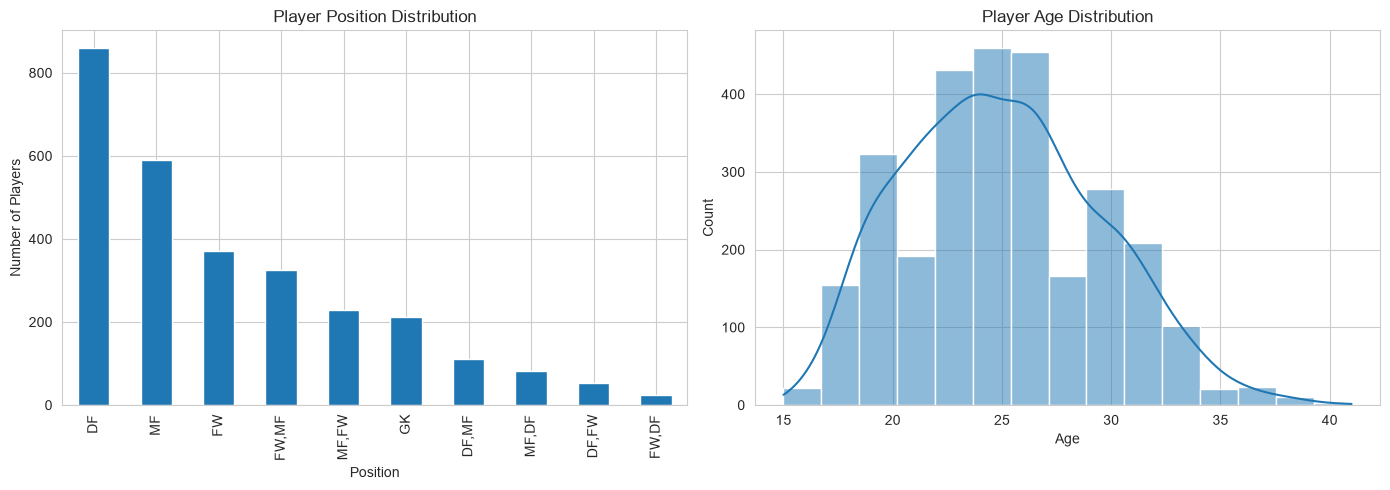

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position distribution
df["Pos"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    title="Player Position Distribution"
)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Number of Players")

# Age distribution
sns.histplot(
    df["Age"].dropna(),
    bins=15,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Player Age Distribution")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

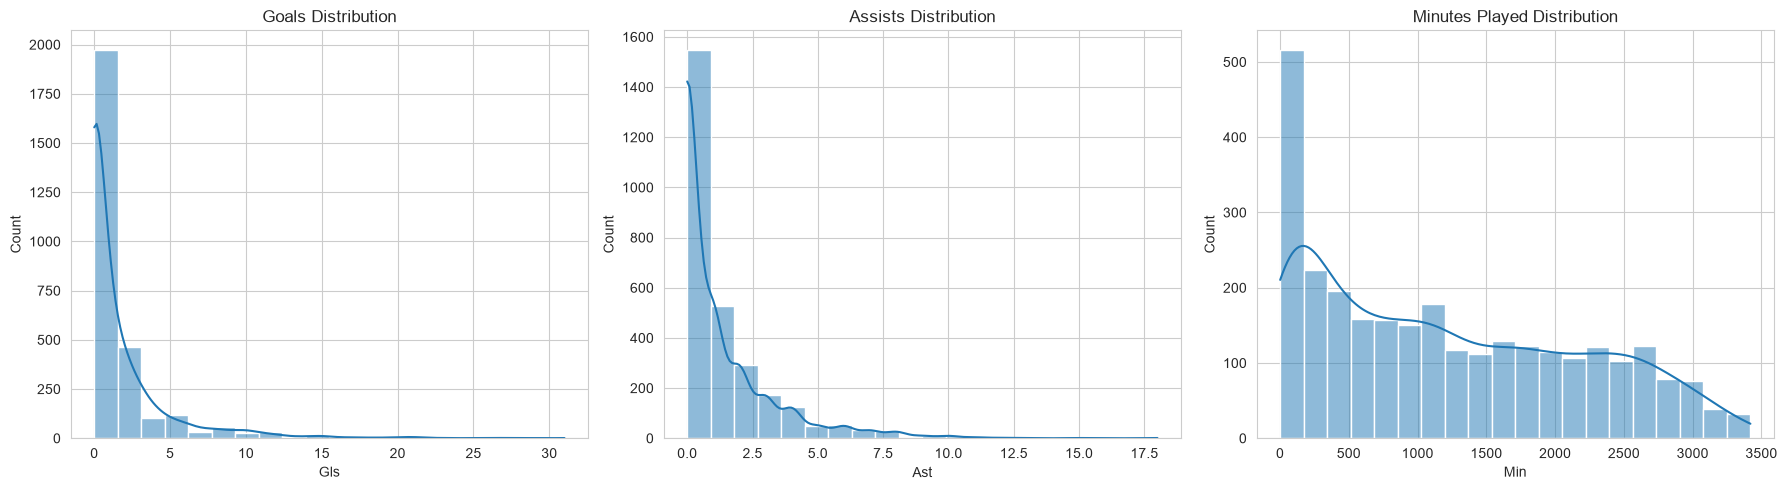

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Gls"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Goals Distribution")

sns.histplot(df["Ast"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Assists Distribution")

sns.histplot(df["Min"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Minutes Played Distribution")

plt.tight_layout()
plt.show()

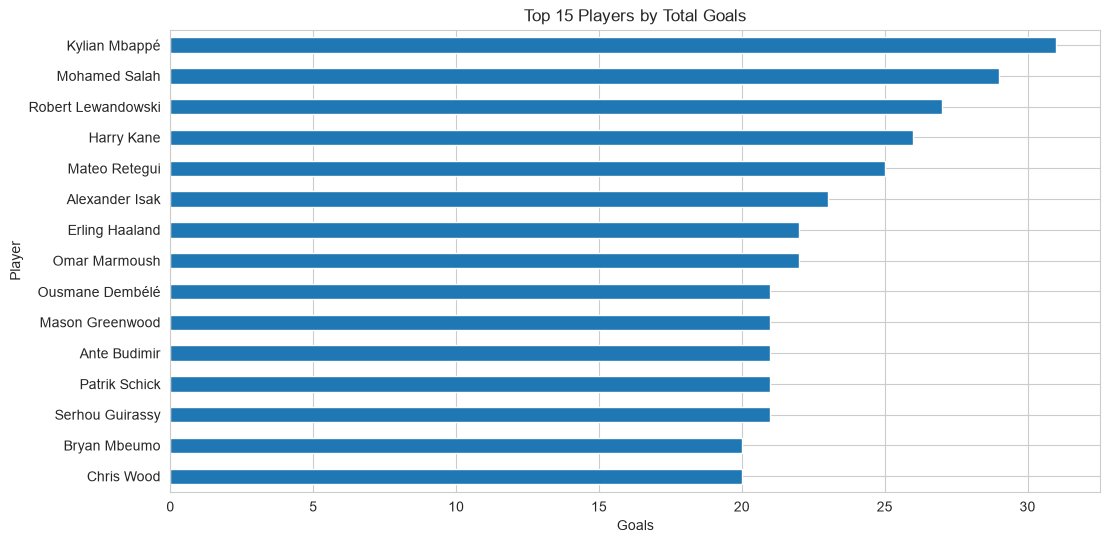

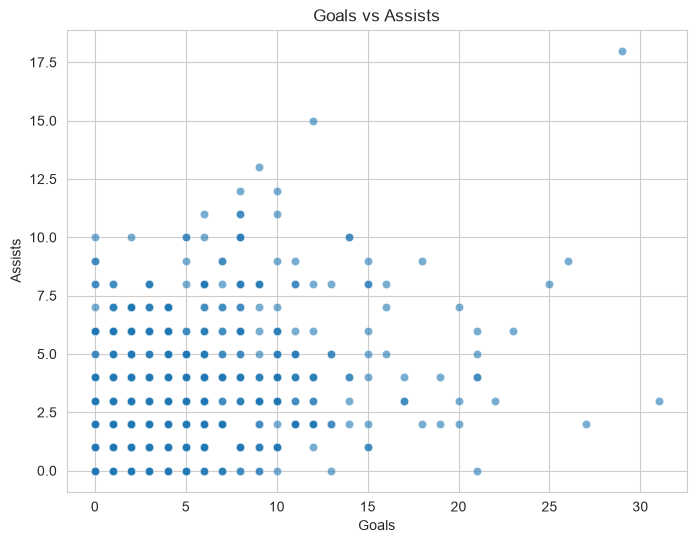

In [ ]:
# Top 15 goal scorers
top_scorers = df.groupby("Player")["Gls"].sum().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))
top_scorers.sort_values().plot(kind="barh")
plt.title("Top 15 Players by Total Goals")
plt.xlabel("Goals")
plt.ylabel("Player")
plt.show()


# Goals vs Assists
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Gls",
    y="Ast",
    alpha=0.6
)

plt.title("Goals vs Assists")
plt.xlabel("Goals")
plt.ylabel("Assists")
plt.show()

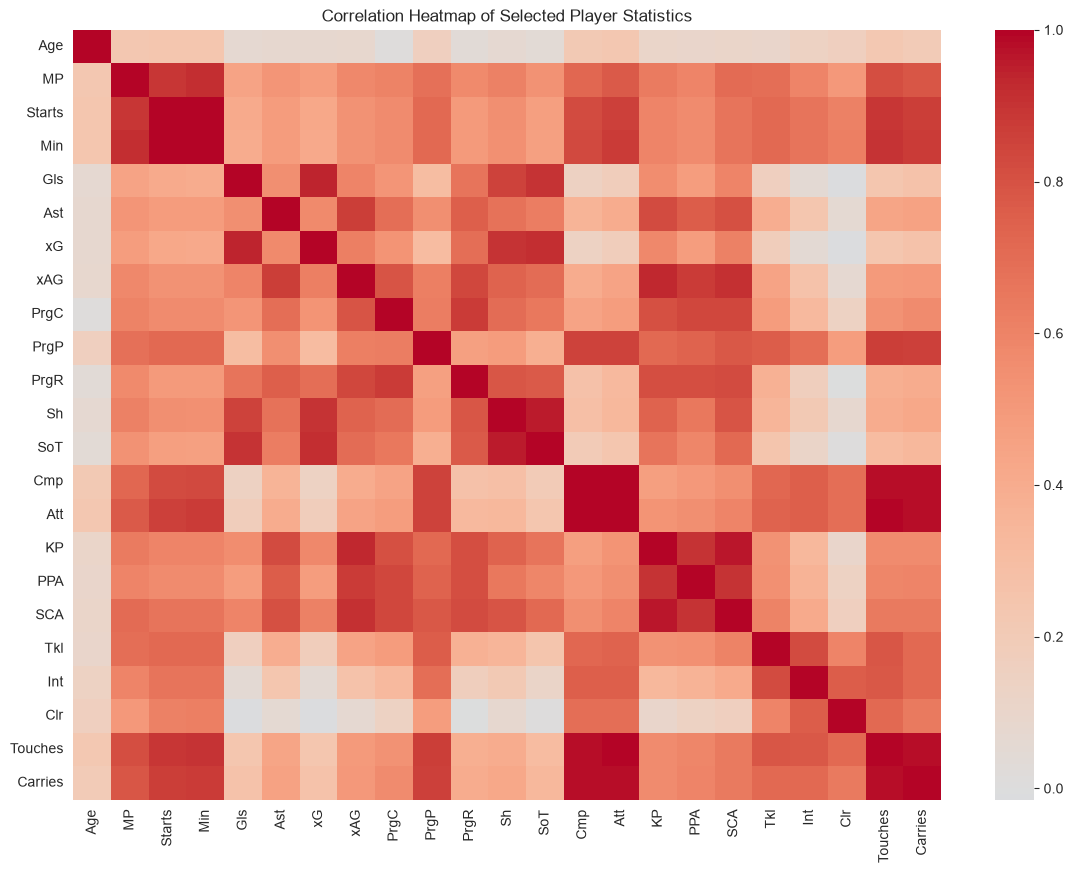

In [ ]:
correlation_features = [
    "Age", "MP", "Starts", "Min",
    "Gls", "Ast", "xG", "xAG",
    "PrgC", "PrgP", "PrgR",
    "Sh", "SoT", "Cmp", "Att",
    "KP", "PPA", "SCA",
    "Tkl", "Int", "Clr",
    "Touches", "Carries"
]

correlation_features = [
    col for col in correlation_features if col in df.columns
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[correlation_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Player Statistics")
plt.show()

In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove completely empty columns
df_clean = df_clean.dropna(axis=1, how="all")

# Replace infinite values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Original Shape:", df.shape)
print("After Cleaning:", df_clean.shape)


Original Shape: (2854, 267)
After Cleaning: (2854, 267)


In [ ]:
# Ranking columns are not useful for player similarity
ranking_columns = [
    col for col in df_clean.columns
    if col == "Rk" or col.startswith("Rk_")
]

# Repeated metadata columns created from different statistical sections
metadata_keywords = [
    "Nation_", "Pos_", "Squad_", "Comp_",
    "Age_", "Born_", "Player_"
]

repeated_metadata = [
    col for col in df_clean.columns
    if any(col.startswith(keyword) for keyword in metadata_keywords)
]

columns_to_remove = list(set(ranking_columns + repeated_metadata))

df_clean = df_clean.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("Removed Columns:", len(columns_to_remove))
print("Remaining Columns:", len(df_clean.columns))
print("New Dataset Shape:", df_clean.shape)

Removed Columns: 61
Remaining Columns: 206
New Dataset Shape: (2854, 206)


In [ ]:
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
display(
    df_clean.isnull().sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nRemaining Columns:")
print(df_clean.columns.tolist())

Cleaned Dataset Shape: (2854, 206)

Remaining Missing Values:


CS%                      2651
Save%                    2648
PSxG/SoT                 2648
AvgDist                  2646
Cmp%_stats_keeper_adv    2644
Stp%                     2643
D                        2642
PKm                      2642
PKsv                     2642
PKA                      2642
PKatt_stats_keeper       2642
#OPA/90                  2642
CS                       2642
L                        2642
W                        2642
dtype: int64


Remaining Columns:
['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', '90s_stats_passing', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', '90s_stats_passing_types', 'Att_stats_passing_types', 'Live', 'Dead', 'FK_stats_passing_types', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Cmp_stats_passing_types', 'Off', 'Blocks', '90s_stats_gca', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Sh_stats_gca', 'Fld', 'Def', 'GCA', 'GCA90', '90s_stats_defense', 'Tkl', 'TklW', 'Def 3rd',

In [ ]:
performance_features = [
    "Age",
    "MP",
    "Starts",
    "Min",
    "90s",
    "Gls",
    "Ast",
    "G+A",
    "G-PK",
    "xG",
    "xAG",
    "npxG+xAG",
    "PrgC",
    "PrgP",
    "PrgR",
    "Sh",
    "SoT",
    "SoT%",
    "Cmp",
    "Att",
    "Cmp%",
    "xA",
    "KP",
    "PPA",
    "SCA",
    "SCA90",
    "Tkl",
    "TklW",
    "Int",
    "Tkl+Int",
    "Clr",
    "Touches",
    "Succ",
    "Succ%",
    "Carries",
    "CPA",
    "Rec",
    "Won",
    "Won%"
]

# Keep only columns that actually exist
performance_features = [
    col for col in performance_features
    if col in df_clean.columns
]

print("Number of Selected Features:", len(performance_features))
print("\nSelected Features:")
print(performance_features)

Number of Selected Features: 39

Selected Features:
['Age', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'xG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Sh', 'SoT', 'SoT%', 'Cmp', 'Att', 'Cmp%', 'xA', 'KP', 'PPA', 'SCA', 'SCA90', 'Tkl', 'TklW', 'Int', 'Tkl+Int', 'Clr', 'Touches', 'Succ', 'Succ%', 'Carries', 'CPA', 'Rec', 'Won', 'Won%']


In [ ]:
# Prepare Player-Level Performance Data

# Select performance features
player_features = df_clean[
    ["Player"] + performance_features
].copy()

# Convert performance features to numeric
player_features[performance_features] = (
    player_features[performance_features]
    .apply(pd.to_numeric, errors="coerce")
)

# Replace infinite values
player_features = player_features.replace(
    [np.inf, -np.inf],
    np.nan
)

# Aggregate multiple records of the same player
# using the mean of their performance statistics
player_features = (
    player_features
    .groupby("Player", as_index=False)[performance_features]
    .mean()
)

# Create player information table
player_info = (
    df_clean[
        ["Player", "Nation", "Pos", "Squad", "Age"]
    ]
    .drop_duplicates(subset="Player")
    .reset_index(drop=True)
)

# Match player information with aggregated features
player_info = player_info[
    player_info["Player"].isin(
        player_features["Player"]
    )
].copy()

# Keep the same player order
player_info = (
    player_info
    .set_index("Player")
    .loc[player_features["Player"]]
    .reset_index()
)

# Feature matrix
X = player_features[
    performance_features
].copy()

# Fill remaining missing values using median
X = X.fillna(X.median())

# Reset indexes
X = X.reset_index(drop=True)
player_info = player_info.reset_index(drop=True)

print("Original Records:", len(df_clean))
print("Unique Players:", player_info["Player"].nunique())

print("\nFeature Matrix Shape:", X.shape)
print("Player Information Shape:", player_info.shape)

print(
    "\nMissing Values After Imputation:",
    X.isnull().sum().sum()
)

Original Records: 2854
Unique Players: 2702

Feature Matrix Shape: (2702, 39)
Player Information Shape: (2702, 5)

Missing Values After Imputation: 0


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=performance_features,
    index=X.index
)

print("Scaled Feature Matrix:")
display(X_scaled.head())

Scaled Feature Matrix:


,Age,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,xG,...,Tkl+Int,Clr,Touches,Succ,Succ%,Carries,CPA,Rec,Won,Won%
0,-1.335324,-1.614202,-1.222104,-1.286538,-1.287472,-0.539515,-0.628613,-0.645664,-0.559369,-0.609760,...,-0.992360,-0.753327,-1.151595,-0.722100,-0.047442,-1.115007,-0.512338,-1.104656,-0.788511,0.013592
1,1.978661,-0.127312,-0.340150,-0.434257,-0.430038,-0.539515,-0.628613,-0.645664,-0.559369,-0.539859,...,-0.384600,0.170834,-0.102051,-0.643050,0.222928,-0.339310,-0.512338,-0.121476,-0.464817,0.081693
2,-1.556257,-1.614202,-1.222104,-1.285502,-1.287472,-0.539515,-0.628613,-0.645664,-0.559369,-0.609760,...,-0.992360,-0.753327,-1.151595,-0.722100,-0.047442,-1.112341,-0.512338,-1.102406,-0.788511,0.013592
3,0.211202,0.922258,1.423759,1.508489,1.508508,-0.539515,-0.628613,-0.645664,-0.559369,-0.609760,...,-0.928385,-0.503554,0.855830,-0.722100,-0.047442,0.980175,-0.512338,0.474732,-0.511059,2.351730
4,0.211202,1.447043,1.864736,1.978642,1.974504,0.086944,1.915212,0.882279,0.150716,-0.190357,...,3.357921,2.368838,2.294943,4.337108,0.340481,1.795857,0.816456,1.869634,0.228814,-0.372315


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.49363062 0.19013456]

Total Variance Explained: 0.6837651780191638


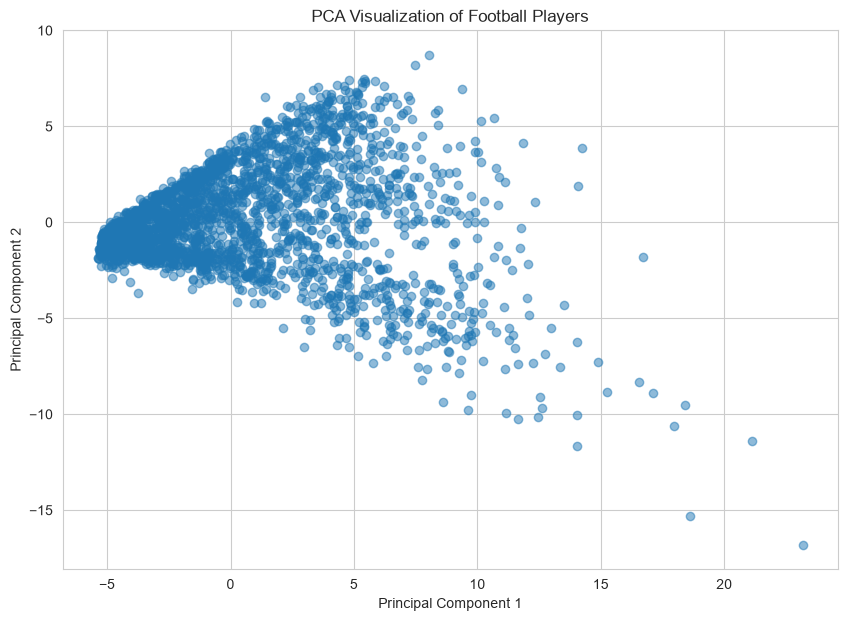

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Football Players")

plt.show()

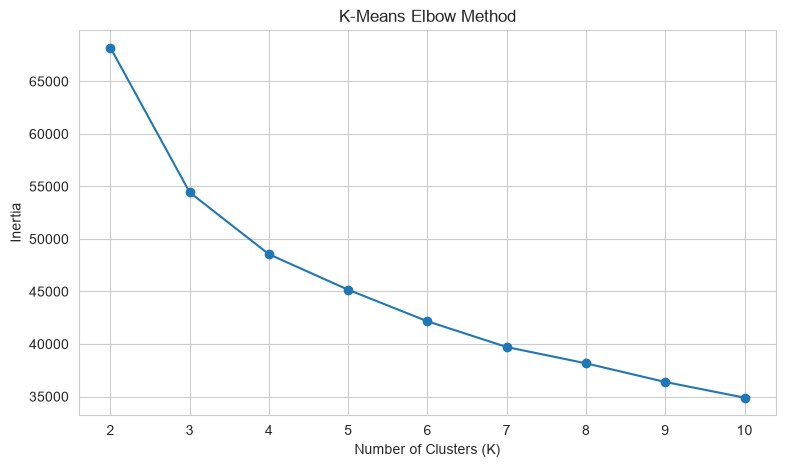

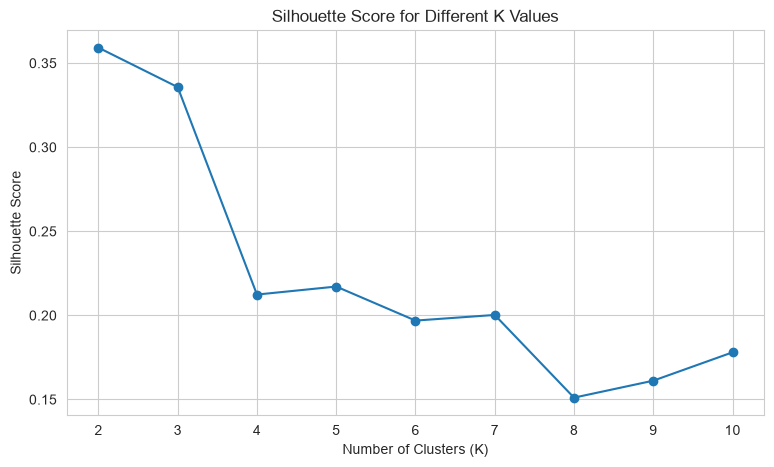

In [ ]:
# K-Means Elbow Method and Silhouette Analysis

inertias = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )


# Elbow Curve
plt.figure(figsize=(9, 5))

plt.plot(
    K_range,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.xticks(list(K_range))
plt.show()


# Silhouette Score Curve
plt.figure(figsize=(9, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(list(K_range))
plt.show()

In [ ]:
# K-Means Clustering + Evaluation

# Select K based on silhouette analysis
optimal_k = K_range[np.argmax(silhouette_scores)]

print("Selected Number of Clusters:", optimal_k)

# Train final K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
silhouette_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

ch_kmeans = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

print("\nK-Means Results")
print("----------------")
print("Silhouette Score:", silhouette_kmeans)
print("Davies-Bouldin Index:", db_kmeans)
print("Calinski-Harabasz Score:", ch_kmeans)

Selected Number of Clusters: 2

K-Means Results
----------------
Silhouette Score: 0.35919341790998155
Davies-Bouldin Index: 1.2597019455181582
Calinski-Harabasz Score: 1471.2484038831421


In [ ]:
agg = AgglomerativeClustering(
    n_clusters=optimal_k
)

agg_labels = agg.fit_predict(X_scaled)

silhouette_agg = silhouette_score(
    X_scaled,
    agg_labels
)

db_agg = davies_bouldin_score(
    X_scaled,
    agg_labels
)

ch_agg = calinski_harabasz_score(
    X_scaled,
    agg_labels
)

print("Agglomerative Clustering Results")
print("--------------------------------")
print("Silhouette Score:", silhouette_agg)
print("Davies-Bouldin Index:", db_agg)
print("Calinski-Harabasz Score:", ch_agg)

Agglomerative Clustering Results
--------------------------------
Silhouette Score: 0.3571584325797984
Davies-Bouldin Index: 1.329263005467167
Calinski-Harabasz Score: 1290.52703144573


In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = set(dbscan_labels)

# Remove noise (-1) for evaluation
valid_mask = dbscan_labels != -1

if len(unique_labels - {-1}) >= 2:

    silhouette_dbscan = silhouette_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    ch_dbscan = calinski_harabasz_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    print("DBSCAN Results")
    print("--------------")
    print("Silhouette Score:", silhouette_dbscan)
    print("Davies-Bouldin Index:", db_dbscan)
    print("Calinski-Harabasz Score:", ch_dbscan)

else:
    silhouette_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan

    print("DBSCAN did not produce enough clusters for evaluation.")

DBSCAN Results
--------------
Silhouette Score: 0.137188990155959
Davies-Bouldin Index: 1.3412590338444454
Calinski-Harabasz Score: 62.076411477267975


In [ ]:
gmm = GaussianMixture(
    n_components=optimal_k,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

silhouette_gmm = silhouette_score(
    X_scaled,
    gmm_labels
)

db_gmm = davies_bouldin_score(
    X_scaled,
    gmm_labels
)

ch_gmm = calinski_harabasz_score(
    X_scaled,
    gmm_labels
)

print("Gaussian Mixture Model Results")
print("------------------------------")
print("Silhouette Score:", silhouette_gmm)
print("Davies-Bouldin Index:", db_gmm)
print("Calinski-Harabasz Score:", ch_gmm)

Gaussian Mixture Model Results
------------------------------
Silhouette Score: 0.23885969084804012
Davies-Bouldin Index: 1.3920836506345977
Calinski-Harabasz Score: 1069.5488898176907


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative",
        "DBSCAN",
        "Gaussian Mixture"
    ],

    "Silhouette Score": [
        silhouette_kmeans,
        silhouette_agg,
        silhouette_dbscan,
        silhouette_gmm
    ],

    "Davies-Bouldin Index": [
        db_kmeans,
        db_agg,
        db_dbscan,
        db_gmm
    ],

    "Calinski-Harabasz Score": [
        ch_kmeans,
        ch_agg,
        ch_dbscan,
        ch_gmm
    ]
})

display(
    comparison.sort_values(
        "Silhouette Score",
        ascending=False
    )
)

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.359193,1.259702,1471.248404
1,Agglomerative,0.357158,1.329263,1290.527031
3,Gaussian Mixture,0.238860,1.392084,1069.548890
2,DBSCAN,0.137189,1.341259,62.076411


Best Clustering Model: K-Means


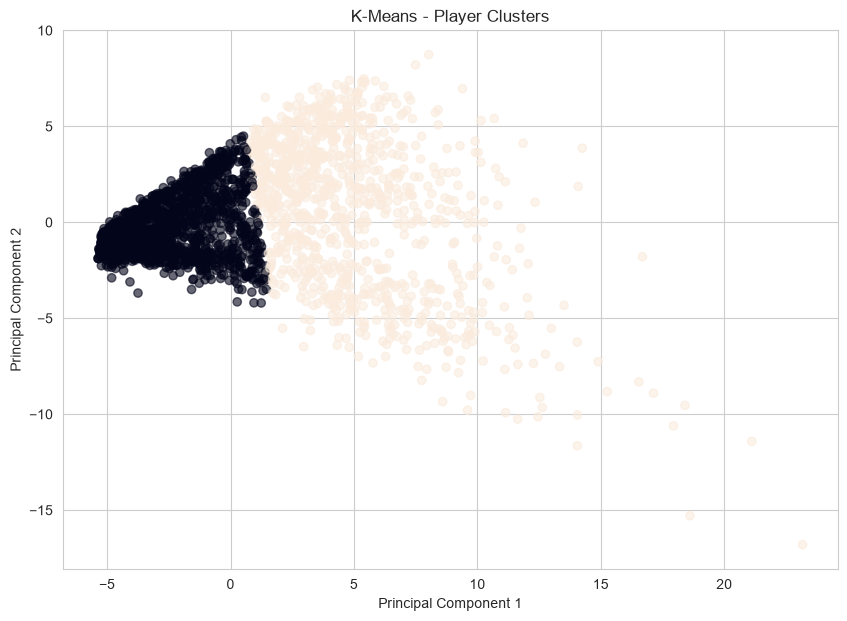

In [ ]:
# Best Model Selection + Cluster Visualization

best_model = comparison.loc[
    comparison["Silhouette Score"].idxmax(),
    "Model"
]

print("Best Clustering Model:", best_model)


# Select labels according to the best model
if best_model == "K-Means":
    best_labels = kmeans_labels

elif best_model == "Agglomerative":
    best_labels = agg_labels

elif best_model == "DBSCAN":
    best_labels = dbscan_labels

elif best_model == "Gaussian Mixture":
    best_labels = gmm_labels

else:
    best_labels = kmeans_labels


# Visualize Best Model Clusters
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=best_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"{best_model} - Player Clusters")

plt.show()

In [ ]:
# Cosine Similarity

similarity_matrix = cosine_similarity(X_scaled)

print("Cosine Similarity Matrix Created.")
print("Matrix Shape:", similarity_matrix.shape)

Cosine Similarity Matrix Created.
Matrix Shape: (2702, 2702)


In [ ]:
# Find Top Similar Players

def find_similar_players(player_name, top_n=5):

    # Find player index
    player_indices = player_info[
        player_info["Player"] == player_name
    ].index.tolist()

    if len(player_indices) == 0:
        print("Player not found.")
        return

    player_index = player_indices[0]

    # Get similarity scores
    similarities = similarity_matrix[player_index]

    # Create result table
    result = pd.DataFrame({
        "Player": player_info["Player"].values,
        "Cosine Similarity": similarities
    })

    # Remove selected player
    result = result[
        result["Player"] != player_name
    ]

    # Sort by similarity
    result = result.sort_values(
        "Cosine Similarity",
        ascending=False
    )

    return result.head(top_n).reset_index(drop=True)

In [ ]:
# Test Player Similarity

test_player = player_info["Player"].iloc[0]

print("Selected Player:", test_player)

similar_players = find_similar_players(
    test_player,
    top_n=5
)

display(similar_players)

Selected Player: Aaron Ciammaglichella


,Player,Cosine Similarity
0,Ayanda Sishuba,0.999949
1,Sékou Doucoure,0.999651
2,Julio Soler,0.999449
3,Remy Rees-Dottin,0.999262
4,Michael Golding,0.999262


In [ ]:
# Add Best Model Cluster Information

result_df = player_info.copy()

result_df["Cluster"] = best_labels

# Show selected player's profile
player_profile = result_df[
    result_df["Player"] == test_player
]

display(player_profile)

,Player,Nation,Pos,Squad,Age,Cluster
0,Aaron Ciammaglichella,it ITA,MF,Torino,19.0,0


# Final Results and Conclusion

## Results

The football player dataset was successfully analyzed using an unsupervised machine learning approach.

The project included:

- Exploratory Data Analysis
- Data Cleaning
- Player-Level Data Preparation
- Feature Selection
- Missing Value Handling
- Feature Scaling
- PCA Dimensionality Reduction
- K-Means Clustering
- Agglomerative Clustering
- DBSCAN
- Gaussian Mixture Model
- Model Comparison
- Cosine Similarity

The clustering algorithms were evaluated using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score

Among the tested clustering algorithms, **K-Means performed the best overall** based on the evaluation metrics.

The final system uses **Cosine Similarity** to identify the Top 5 players with the most similar statistical profiles.

## Conclusion

This project demonstrates how unsupervised machine learning can be used to analyze football player statistics and identify players with similar performance characteristics.

The results show that K-Means was the most suitable clustering approach for the given dataset among the tested models.

The player similarity system can assist sports organizations in player scouting, recruitment, team building, and identifying potential alternatives for players with similar statistical profiles.

The project can be further extended into an interactive Streamlit application where users can select a player and receive recommendations for similar players.